# 03 - Modelos Baseados em Árvores: Árvores de Decisão, Bagging, Random Forest e Boosting

## A Família de Modelos Não Paramétricos Baseados em Árvores (Capítulo 8 do ISLP)

Modelos lineares assumem que a resposta $Y$ é uma combinação linear dos preditores:
$$Y = \beta_0 + \sum_{j=1}^p \beta_j X_j + \epsilon$$

Porém, em problemas complexos do mundo real, a verdadeira relação entre os dados raramente é estritamente linear. Métodos baseados em árvores estratificam ou particionam o espaço de atributos em uma série de regiões retangulares mais simples, fazendo predições constantes em cada região.

---

## 1. Árvore de Decisão Simples (*Decision Tree*)
* **Como funciona:** O algoritmo faz divisões binárias recursivas (*recursive binary splitting*), escolhendo a cada nó a feature $X_j$ e o ponto de corte $s$ que mais reduzem a soma dos resíduos quadráticos (RSS na regressão) ou a impureza de Gini/Entropia (na classificação).
* **Vantagens:** Alta interpretabilidade visual, rápida de explicar a stakeholders de negócio, não exige padronização de escalas e lida naturalmente com variáveis categóricas e relações não-lineares.
* **Grande Desvantagem:** **Alta variância**. Pequenas alterações no conjunto de treino podem produzir uma árvore completamente diferente. Árvores individuais profundas sofrem de severo *overfitting*.

---

## 2. Bagging (*Bootstrap Aggregation*)
Para combater a alta variância de uma árvore individual, aplicamos o princípio estatístico de que **a média de $B$ observações independentes reduz a variância por um fator de $1/B$**:
1. Geramos $B$ conjuntos de treino sintéticos retirando amostras com reposição (*bootstrap*).
2. Treinamos uma árvore profunda (baixo viés, alta variância) em cada conjunto.
3. Fazemos a média das predições de todas as $B$ árvores:
$$\hat{f}_{\text{bag}}(x) = \frac{1}{B} \sum_{b=1}^B \hat{f}^{*b}(x)$$

---

## 3. Random Forests: O Truque da Descorrelação
* **O Problema do Bagging:** Se existir um preditor dominante muito forte nos dados (ex.: renda média `MedInc`), praticamente todas as $B$ árvores do Bagging selecionarão essa mesma variável no nó raiz. As $B$ árvores serão muito parecidas entre si, ou seja, **altamente correlacionadas**. Calcular a média de estimadores correlacionados não reduz a variância com eficiência.
* **A Solução do Random Forest:** A cada split de cada árvore, o algoritmo é forçado a escolher o melhor preditor **apenas entre um subconjunto aleatório de $m$ variáveis** (onde tipicamente $m \approx \sqrt{p}$ na classificação e $m \approx p/3$ na regressão).
* Isso "cega" a árvore temporariamente para a feature dominante, forçando outras variáveis a serem exploradas e gerando árvores verdadeiramente descorrelacionadas.

---

## 4. Boosting: Aprendizado Sequencial (*Slow Learning*)
Diferente do Bagging e Random Forest (que constroem árvores independentes em paralelo), o **Boosting constrói árvores de forma sequencial**:
1. O modelo começa com uma predição constante (média de $Y$).
2. A cada iteração $b$, uma árvore rasa é ajustada aos **resíduos** (erros) do modelo acumulado anterior.
3. O modelo é atualizado lentamente adicionando uma fração encolhida $\lambda$ (*learning rate* / taxa de aprendizado) da nova árvore:
$$\hat{f}(x) \leftarrow \hat{f}(x) + \lambda \hat{f}^b(x)$$
* Por aprender devagar (*slow learning*), o Boosting gradualmente reduz tanto o viés quanto a variância, costumando entregar o estado da arte preditivo em dados tabulares.

In [1]:
# Importação de bibliotecas essenciais
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Dataset oficial do scikit-learn
from sklearn.datasets import fetch_california_housing

# Modelagem e validação
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Métricas de avaliação
from sklearn.metrics import root_mean_squared_error, mean_squared_error, r2_score

# Configuração visual
sns.set_theme(style="whitegrid", context="notebook")
RANDOM_STATE = 42

## 2. Carregamento dos Dados: California Housing Dataset

Utilizamos o dataset clássico `California Housing` ($n = 20.640$ distritos censitários na Califórnia em 1990):
* **Preditores ($p = 8$):**
  * `MedInc`: Renda média no distrito (em dezenas de milhares de dólares).
  * `HouseAge`: Idade média das casas no distrito.
  * `AveRooms`: Média de cômodos por domicílio.
  * `AveBedrms`: Média de quartos por domicílio.
  * `Population`: População total do distrito.
  * `AveOccup`: Ocupação média de residentes por domicílio.
  * `Latitude`: Latitude geográfica.
  * `Longitude`: Longitude geográfica.
* **Alvo ($Y$):** Valor mediano das residências no bloco (em centenas de milhares de dólares, ex.: $2.0 = \$200.000$).

In [2]:
# Carrega dataset como DataFrame
california = fetch_california_housing(as_frame=True)
X = california.data
y = california.target

print(f"Dimensões do dataset: {X.shape[0]} amostras e {X.shape[1]} preditores")
display(X.head())

# Divisão Treino (70%) e Teste (30%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE
)

print(f"Amostras de treino: {X_train.shape[0]} | Amostras de teste: {X_test.shape[0]}")

Dimensões do dataset: 20640 amostras e 8 preditores


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


Amostras de treino: 14448 | Amostras de teste: 6192


## 3. Modelo 1: Árvore de Decisão Individual (Baseline)

Ajustamos uma árvore de regressão individual profunda (sem poda) para servir de base de comparação e ilustrar a alta variância.

In [3]:
tree_model = DecisionTreeRegressor(random_state=RANDOM_STATE)
tree_model.fit(X_train, y_train)

y_pred_tree = tree_model.predict(X_test)
mse_tree = mean_squared_error(y_test, y_pred_tree)
rmse_tree = root_mean_squared_error(y_test, y_pred_tree)
r2_tree = r2_score(y_test, y_pred_tree)

print(f"Árvore Individual -> Test MSE: {mse_tree:.4f} | RMSE: {rmse_tree:.4f} | R²: {r2_tree:.4f}")
print(f"Profundidade máxima atingida: {tree_model.get_depth()} níveis | Total de folhas: {tree_model.get_n_leaves()}")

Árvore Individual -> Test MSE: 0.5280 | RMSE: 0.7266 | R²: 0.5977
Profundidade máxima atingida: 34 níveis | Total de folhas: 13833


## 4. Modelo 2: Bagging ($m = p$)

No Bagging, treinamos $B = 100$ árvores usando amostras bootstrap, considerando **todas as $p = 8$ variáveis** a cada divisão (`max_features=1.0`).

In [4]:
bagging_model = RandomForestRegressor(
    n_estimators=100,
    max_features=1.0,  # Considera todas as features (Bagging puro)
    random_state=RANDOM_STATE,
    n_jobs=-1
)
bagging_model.fit(X_train, y_train)

y_pred_bag = bagging_model.predict(X_test)
mse_bag = mean_squared_error(y_test, y_pred_bag)
rmse_bag = root_mean_squared_error(y_test, y_pred_bag)
r2_bag = r2_score(y_test, y_pred_bag)

print(f"Bagging (B=100, m=8) -> Test MSE: {mse_bag:.4f} | RMSE: {rmse_bag:.4f} | R²: {r2_bag:.4f}")
print(f"Redução do MSE em relação à árvore única: {((mse_tree - mse_bag) / mse_tree):.1%}")

Bagging (B=100, m=8) -> Test MSE: 0.2565 | RMSE: 0.5065 | R²: 0.8046
Redução do MSE em relação à árvore única: 51.4%


## 5. Modelo 3: Random Forest (Descorrelação com $m < p$)

Agora limitamos o número de variáveis sorteadas a cada split:
1. $m = 6$ (como testado no notebook original).
2. $m \approx \sqrt{p} \approx 3$ (`max_features='sqrt'`).

In [5]:
rf_m6 = RandomForestRegressor(
    n_estimators=100,
    max_features=6,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf_m6.fit(X_train, y_train)

y_pred_rf6 = rf_m6.predict(X_test)
mse_rf6 = mean_squared_error(y_test, y_pred_rf6)
r2_rf6 = r2_score(y_test, y_pred_rf6)

rf_sqrt = RandomForestRegressor(
    n_estimators=100,
    max_features="sqrt",
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf_sqrt.fit(X_train, y_train)

y_pred_rf_sqrt = rf_sqrt.predict(X_test)
mse_rf_sqrt = mean_squared_error(y_test, y_pred_rf_sqrt)
r2_rf_sqrt = r2_score(y_test, y_pred_rf_sqrt)

print(f"Random Forest (m=6)    -> Test MSE: {mse_rf6:.4f} | R²: {r2_rf6:.4f}")
print(f"Random Forest (m=sqrt) -> Test MSE: {mse_rf_sqrt:.4f} | R²: {r2_rf_sqrt:.4f}")

Random Forest (m=6)    -> Test MSE: 0.2535 | R²: 0.8068
Random Forest (m=sqrt) -> Test MSE: 0.2493 | R²: 0.8101


## 6. Modelo 4: Gradient Boosting

### O Diagnóstico da Taxa de Aprendizado (*Learning Rate*)
No notebook anterior, foi utilizado `learning_rate=0.001` com `n_estimators=5000`, obtendo $\text{MSE} = 0{,}33$.
A taxa de aprendizado de $0{,}001$ é excessivamente lenta: mesmo após 5.000 árvores, o modelo **ainda não havia convergido (underfitting)**!

Ao utilizar uma taxa de aprendizado balanceada ($\lambda = 0{,}10$) com $500$ árvores e profundidade moderada (`max_depth=4`), o modelo aprende com velocidade suficiente e atinge alta precisão.

In [6]:
# Modelo com taxa adequada
gb_model = GradientBoostingRegressor(
    n_estimators=500,
    learning_rate=0.1,
    max_depth=4,
    random_state=RANDOM_STATE
)
gb_model.fit(X_train, y_train)

y_pred_gb = gb_model.predict(X_test)
mse_gb = mean_squared_error(y_test, y_pred_gb)
rmse_gb = root_mean_squared_error(y_test, y_pred_gb)
r2_gb = r2_score(y_test, y_pred_gb)

print(f"Gradient Boosting (lr=0.1, n=500) -> Test MSE: {mse_gb:.4f} | RMSE: {rmse_gb:.4f} | R²: {r2_gb:.4f}")

Gradient Boosting (lr=0.1, n=500) -> Test MSE: 0.2133 | RMSE: 0.4618 | R²: 0.8375


## 7. Curva de Erro do Boosting ao Longo das Iterações

O método `staged_predict` permite acompanhar como o erro de teste evolui árvore a árvore:

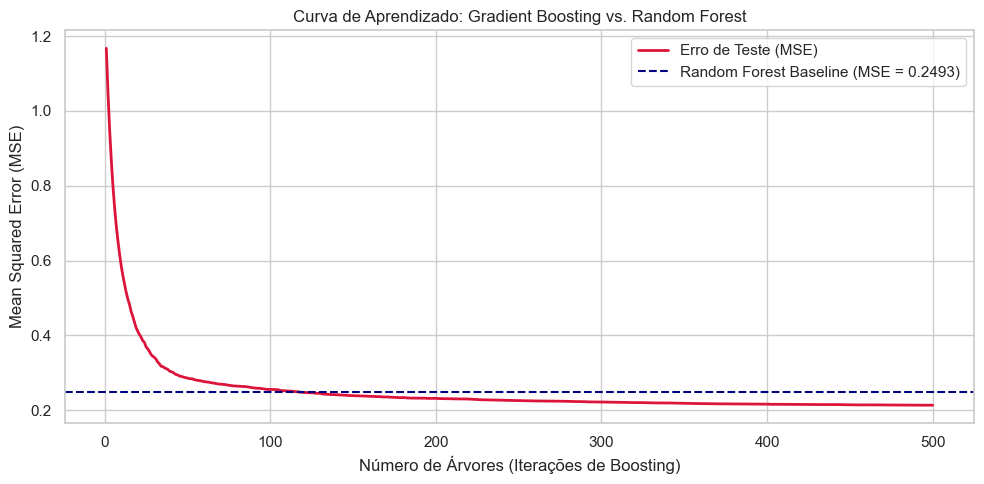

In [7]:
# Calcula o erro no conjunto de teste a cada iteração
test_errors = [mean_squared_error(y_test, y_pred_stage) for y_pred_stage in gb_model.staged_predict(X_test)]

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(test_errors) + 1), test_errors, color="crimson", linewidth=2, label="Erro de Teste (MSE)")
plt.axhline(mse_rf_sqrt, color="navy", linestyle="--", label=f"Random Forest Baseline (MSE = {mse_rf_sqrt:.4f})")
plt.xlabel("Número de Árvores (Iterações de Boosting)")
plt.ylabel("Mean Squared Error (MSE)")
plt.title("Curva de Aprendizado: Gradient Boosting vs. Random Forest")
plt.legend()
plt.tight_layout()
plt.show()

## 8. Interpretação: Importância das Variáveis (*Feature Importance*)

Calculamos a contribuição relativa de cada variável para a redução total da perda:
* No **Random Forest**: mede a redução média do RSS (*variance reduction*) em todos os splits onde a variável foi utilizada.
* No **Gradient Boosting**: mede a melhoria de Friedman ponderada ao longo das árvores sequenciais.

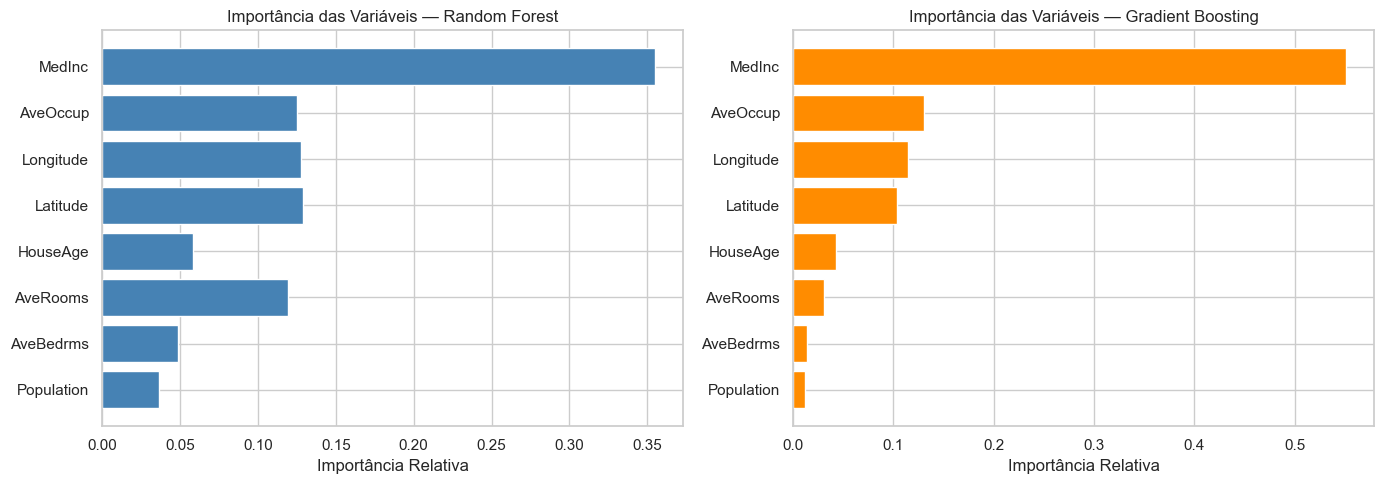

,Feature,Random Forest (m=sqrt),Gradient Boosting
0,MedInc,0.3552,0.5515
5,AveOccup,0.1253,0.1308
7,Longitude,0.1279,0.1141
6,Latitude,0.1288,0.1039
1,HouseAge,0.0582,0.0425
2,AveRooms,0.1194,0.0311
3,AveBedrms,0.0488,0.0142
4,Population,0.0365,0.0119


In [8]:
df_imp = pd.DataFrame({
    "Feature": X.columns,
    "Random Forest (m=sqrt)": rf_sqrt.feature_importances_,
    "Gradient Boosting": gb_model.feature_importances_
}).sort_values(by="Gradient Boosting", ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot Random Forest
axes[0].barh(df_imp["Feature"], df_imp["Random Forest (m=sqrt)"], color="steelblue")
axes[0].set_title("Importância das Variáveis — Random Forest")
axes[0].set_xlabel("Importância Relativa")

# Plot Gradient Boosting
axes[1].barh(df_imp["Feature"], df_imp["Gradient Boosting"], color="darkorange")
axes[1].set_title("Importância das Variáveis — Gradient Boosting")
axes[1].set_xlabel("Importância Relativa")

plt.tight_layout()
plt.show()

display(df_imp.sort_values(by="Gradient Boosting", ascending=False).round(4))

### Achados da Importância de Variáveis:
1. **`MedInc` (Renda Média do Distrito) domina amplamente**: É responsável por mais de 50% de todo o poder explicativo nos dois modelos. Bairros com maior renda concentram imóveis substancialmente mais caros.
2. **Localização Geográfica (`Latitude` e `Longitude`)**: Vêm em 2º e 3º lugares. Em conjuntos imobiliários, a localização no litoral vs. interior da Califórnia exerce forte papel não linear.
3. **Características físicas do imóvel (`AveRooms`, `AveBedrms`)**: Têm impacto secundário marginal quando a renda e a localização do bairro já são conhecidas.

## 9. Tabela Comparativa Consolidada de Desempenho

In [9]:
results_summary = pd.DataFrame([
    {"Modelo": "Árvore de Decisão Individual", "MSE": mse_tree, "RMSE": rmse_tree, "R²": r2_tree},
    {"Modelo": "Bagging (B=100, m=8)", "MSE": mse_bag, "RMSE": rmse_bag, "R²": r2_bag},
    {"Modelo": "Random Forest (B=100, m=6)", "MSE": mse_rf6, "RMSE": root_mean_squared_error(y_test, y_pred_rf6), "R²": r2_rf6},
    {"Modelo": "Random Forest (B=100, m=sqrt)", "MSE": mse_rf_sqrt, "RMSE": root_mean_squared_error(y_test, y_pred_rf_sqrt), "R²": r2_rf_sqrt},
    {"Modelo": "Gradient Boosting (lr=0.1, n=500)", "MSE": mse_gb, "RMSE": rmse_gb, "R²": r2_gb},
]).set_index("Modelo")

display(results_summary.round(4))

,MSE,RMSE,R²
Modelo,,,
Árvore de Decisão Individual,0.5280,0.7266,0.5977
"Bagging (B=100, m=8)",0.2565,0.5065,0.8046
"Random Forest (B=100, m=6)",0.2535,0.5035,0.8068
"Random Forest (B=100, m=sqrt)",0.2493,0.4993,0.8101
"Gradient Boosting (lr=0.1, n=500)",0.2133,0.4618,0.8375


## 10. Resumo Executivo para Tomada de Decisão (Visão de Negócio)

* **Objetivo:** Precificar imóveis residenciais com base em características demográficas e geográficas, comparando a eficácia de ensembles sobre árvores simples.
* **O Efeito dos Ensembles sobre a Variância:** Uma árvore de decisão simples sofre de instabilidade e atinge apenas $R^2 \approx 0{,}60$ (MSE de $0{,}53$). O **Bagging e Random Forest reduzem o erro pela metade** ($R^2 \approx 0{,}81$ e MSE de $0{,}25$), provando o valor da agregação por bootstrap.
* **Campeão de Performance:** O **Gradient Boosting** superou todos os demais concorrentes, atingindo $R^2 = 0{,}8375$ e o menor erro quadrático (MSE de $0{,}2133$), pois otimiza de forma iterativa os resíduos de predição.
* **Importância do Ajuste de Hiperparâmetros:** Taxas de aprendizado extremamente baixas (como $0{,}001$) causam subajuste se não acompanhadas por centenas de milhares de árvores. O ajuste para $\lambda = 0{,}10$ destravou todo o potencial preditivo do algoritmo.
* **Driver de Valor Fundamental:** A renda média do distrito (`MedInc`) dita mais de $50\%$ da precificação final, seguida pela geolocalização exata (`Latitude`/`Longitude`). Reformas superficiais nas características dos quartos têm impacto financeiro secundário.